# Status-stratified concentration — a predominantly null result

**Status: v0.8, frozen 2026-05-23.** Built honestly: after a full verification battery this
analysis returns **one** robust positive result and otherwise null or baseline-artefact results.
It is written to say exactly that.

## What this set out to test
Notebook 07 found announcement-stage (Proposed/Anticipated) first-entries concentrate
cross-catchmently within quarters. This notebook asks whether the *lifecycle* statuses —
**Committed** (capital herding), **Existing** (energisation), **Withdrawn** (failure) — concentrate
within **transmission corridors** (the 5 SLD-topology clusters), within quarters, beyond an
even-across-catchments spread.

## What it actually found (headline, stated up front)
- **Committed, corridor level: null.** No within-quarter coordinated concentration (p = 0.40).
- **Existing, corridor level: null / baseline artefact.** Significant only against the
  equal-per-catchment c2 baseline (p = 0.0093); **dissolves** under an activity-weighted baseline
  (p = 0.116, fails the permutation gate).
- **SW-NSW energisation: the one robust positive** — a *single catchment*, not a corridor;
  survives uniform, activity-weighted (footprint) and proponent-deduplicated baselines (p ≈ 0.021).
- **Withdrawn: descriptive only** (21 events, underpowered).
- **Methodological finding:** the c2 catchment-count baseline manufactures corridor tilts when
  catchment activity is uneven within a corridor (§6).
- **Structural conclusion:** the corridor is *not* the unit at which this phenomenon operates (§7).

The corridor framing this notebook set out to test is **not supported**. A clean null is the result.

## Method (same panel/censoring as notebooks 06–07)
First-appearance events, ≤1 per project per status, after the 2020-02 left-censoring boundary;
phantom-cleaned (`phantom_risk < 2`). **Existing is leak-corrected**: only projects with a prior
observed `Committed` status (genuine within-window Committed→Existing energisation). Five corridors
from `cluster_definitions_proposal.md`. Multinomial-bootstrap calibration; permutation gate
(reassign labels by the baseline, preserving window totals) on every inferential claim.

## §0 Setup — events, statuses, leak-corrected Existing

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from nem_herding.projects import load_all_releases, join_catchment
pd.set_option('display.width',200); pd.set_option('display.max_columns',30)
p=Path.cwd()
while not (p/'pyproject.toml').exists() and p!=p.parent: p=p.parent
REPO=p; DATA=REPO/'data'

panel=load_all_releases(DATA/'projects'/'aemo_geninfo')
panel=join_catchment(panel, DATA/'rez'/'transmission_catchment_lookup.csv')
lk=pd.read_csv(DATA/'rez'/'transmission_catchment_lookup.csv')
panel=panel.merge(lk[['site_name','phantom_risk']],on='site_name',how='left',suffixes=('','_lk'))
panel['phantom_risk']=pd.to_numeric(panel['phantom_risk'],errors='coerce').fillna(0).astype(int)
pc=panel[panel['phantom_risk']<2].copy()
pc['sb']=pc['status_bucket'].astype(str).str.strip()
ds=pc['release_date'].min(); allr=sorted(pc['release_date'].unique())
post=[w for w in allr if w>ds]; POS={w:i for i,w in enumerate(post)}

REZ=['CWO','HCC','NEW','SW-NSW','ILW','CN-VIC','MR','WV','GIP','SW-VIC','MN','SE-SA','RIV','EYR','TAS-NW',
     'WD','SD','DD','TG','WG','FNQ','CQ','SEQ']
CL=['Central-Northern NSW','Southern QLD','Western Victoria','Northern Victoria','Eastern SA']
NCAT={'Central-Northern NSW':3,'Southern QLD':5,'Eastern SA':2,'Western Victoria':2,'Northern Victoria':2}
C2=np.array([NCAT[c] for c in CL],float); C2=C2/C2.sum()
CLUSTER={**{c:'Central-Northern NSW' for c in ['CWO','HCC','NEW']},**{c:'Southern QLD' for c in ['WD','SD','DD','TG','WG']},
         **{c:'Eastern SA' for c in ['MN','RIV']},**{c:'Western Victoria' for c in ['WV','SW-VIC']},
         **{c:'Northern Victoria' for c in ['CN-VIC','MR']}}
pc['cluster']=pc['catchment'].map(CLUSTER)
SINGLETONS=['SW-NSW','ILW','SE-SA','GIP','CQ','TAS-NW','FNQ','SEQ','EYR']

def first_at(mask):
    s=pc[mask].sort_values('release_date').groupby('site_name',as_index=False).first()
    return s[['site_name','release_date','catchment','cluster','owner']].rename(columns={'release_date':'ev'})
committed=first_at(pc.sb=='Committed'); committed=committed[committed.ev>ds].copy()
cmin=pc[pc.sb=='Committed'].groupby('site_name')['release_date'].min()
ef=first_at(pc.sb=='Existing less Announced Withdrawal'); ef['cf']=ef.site_name.map(cmin)
existing=ef[(ef.cf.notna())&(ef.cf<ef.ev)&(ef.ev>ds)].copy()   # leak-corrected
withdrawn=first_at(pc.sb.isin(['Withdrawn','Announced Withdrawal'])); withdrawn=withdrawn[withdrawn.ev>ds].copy()

def setup_row(name, ev):
    return {'status':name,'events':len(ev),'in_5_clusters':int(ev.cluster.isin(CL).sum()),
            'in_singletons':int(ev.catchment.isin(SINGLETONS).sum()),
            'unclassified':int((~ev.catchment.isin(REZ)).sum())}
print(pd.DataFrame([setup_row('Committed',committed),
                    setup_row('Existing (leak-corrected)',existing),
                    setup_row('Withdrawn',withdrawn)]).to_string(index=False))
print(f"\nanalysis windows (post-censoring): {len(post)}   left-censor boundary: {pd.Timestamp(ds).date()}")

                   status  events  in_5_clusters  in_singletons  unclassified
                Committed     133             75             52             6
Existing (leak-corrected)     107             59             45             3
                Withdrawn      21              7              7             7

analysis windows (post-censoring): 21   left-censor boundary: 2020-02-01


In [2]:
# --- statistics (multinomial-bootstrap concentration; permutation gate) ---
def fisher_p(pvals, floor):
    p=np.maximum(np.asarray([x for x in pvals if not np.isnan(x)],float),floor)
    if len(p)==0: return np.nan
    return float(stats.chi2.sf(-2*np.sum(np.log(p)), 2*len(p)))

# corridor activity-weighted baseline: lagged all-status corridor activity share
_act=pc[pc.catchment.isin(list(CLUSTER))].copy(); _act['cluster']=_act.catchment.map(CLUSTER)
_expoCL=_act.groupby(['release_date','cluster']).size().unstack(fill_value=0).reindex(columns=CL,fill_value=0).reindex(index=allr,fill_value=0)
_elCL=_expoCL.shift(1)
def cl_share(w, baseline):
    if baseline=='c2': return C2
    row=_elCL.loc[w,CL].values.astype(float); tot=row.sum()
    return row/tot if tot>0 else None

def cluster_conc(ev, baseline, B=100000, seed=7, minn=3, width=1):
    sub=ev[ev.cluster.isin(CL)].copy(); sub['bin']=sub.ev.map(lambda w: POS[w]//width)
    # representative window per bin for the activity baseline = last release in bin
    binrep={b:post[min((b+1)*width-1,len(post)-1)] for b in sub['bin'].unique()}
    wc=sub.groupby(['bin','cluster']).size().unstack(fill_value=0).reindex(columns=CL,fill_value=0)
    rng=np.random.default_rng(seed); ps=[]; AO=np.zeros(5); AE=np.zeros(5)
    for b,row in wc.iterrows():
        obs=row.values.astype(float); n=int(obs.sum())
        if n<minn: continue
        exp=cl_share(binrep[b], baseline)
        if exp is None: continue
        expv=n*exp; AO+=obs; AE+=expv; stat=((obs-expv)**2/expv).sum()
        sims=rng.multinomial(n,exp,size=B).astype(float)
        cnt=int((((sims-expv[None,:])**2/expv[None,:]).sum(axis=1)>=stat).sum()); ps.append((cnt+1)/(B+1))
    return dict(combined_p=fisher_p(ps,1/(B+1)), k=len(ps), agg_obs=AO, agg_exp=AE)

def cluster_perm(ev, baseline, nperm=120, B=10000, width=1):
    sub=ev[ev.cluster.isin(CL)].copy(); sub['bin']=sub.ev.map(lambda w: POS[w]//width)
    binrep={b:post[min((b+1)*width-1,len(post)-1)] for b in sub['bin'].unique()}; bc=sub.groupby('bin').size(); out=[]
    for kk in range(nperm):
        rng=np.random.default_rng(5000+kk); rows=[]
        for b,n in bc.items():
            exp=cl_share(binrep[b],baseline)
            if exp is None: continue
            rows.append(pd.DataFrame({'bin':[b]*int(n),'cluster':rng.choice(CL,size=int(n),p=exp)}))
        perm=pd.concat(rows,ignore_index=True)
        wc=perm.groupby(['bin','cluster']).size().unstack(fill_value=0).reindex(columns=CL,fill_value=0)
        rng2=np.random.default_rng(9000+kk); ps=[]
        for b,row in wc.iterrows():
            obs=row.values.astype(float); n=int(obs.sum())
            if n<3: continue
            exp=cl_share(binrep[b],baseline); expv=n*exp; stat=((obs-expv)**2/expv).sum()
            sims=rng2.multinomial(n,exp,size=B).astype(float)
            cnt=int((((sims-expv[None,:])**2/expv[None,:]).sum(axis=1)>=stat).sum()); ps.append((cnt+1)/(B+1))
        out.append(fisher_p(ps,1/(B+1)))
    return np.array(out)

# SW-NSW single-catchment (uniform 1/23 or footprint = lagged SW-NSW all-status share among REZ)
_expoR=pc.groupby(['release_date','catchment']).size().unstack(fill_value=0).reindex(columns=REZ,fill_value=0).reindex(index=allr,fill_value=0)
_elR=_expoR.shift(1)
def sw_p0(w, baseline):
    if baseline=='uniform': return 1/len(REZ)
    row=_elR.loc[w,REZ]; tot=row.sum(); return float(row['SW-NSW']/tot) if tot>0 else 1/len(REZ)
def sw_test(ev, baseline, B=100000, seed=9, minn=3):
    incl=ev[ev.catchment.isin(REZ)].copy(); incl['sw']=(incl.catchment=='SW-NSW')
    g=incl.groupby('ev')['sw'].agg(['sum','count']); rng=np.random.default_rng(seed); ps=[]
    for w,r in g.iterrows():
        k=int(r['sum']); n=int(r['count'])
        if n<minn: continue
        sims=rng.binomial(n,sw_p0(w,baseline),size=B); ps.append((int((sims>=k).sum())+1)/(B+1))
    return fisher_p(ps,1/(B+1)), len(ps)
def sw_perm(ev, baseline, nperm=80, B=10000):
    incl=ev[ev.catchment.isin(REZ)]; wcnt=incl.groupby('ev').size(); out=[]
    for kk in range(nperm):
        rng=np.random.default_rng(3000+kk); rows=[]
        for w,n in wcnt.items():
            pr=(_elR.loc[w,REZ]/_elR.loc[w,REZ].sum()).values if baseline=='footprint' and _elR.loc[w,REZ].sum()>0 else None
            cats=rng.choice(REZ,size=int(n),p=pr) if pr is not None else rng.choice(REZ,size=int(n))
            rows.append(pd.DataFrame({'ev':[w]*int(n),'catchment':cats}))
        rp,_=sw_test(pd.concat(rows,ignore_index=True),baseline,B=B,seed=7000+kk); out.append(rp)
    return np.array(out)
def dedup(ev): return ev.drop_duplicates(subset=['ev','catchment','owner'])
def verdict(real,perm):
    pp=np.mean(perm<=real); return ('PASS' if (real<0.05 and pp<0.05) else ('null' if real>=0.05 else 'fails-perm')), pp
print('helpers ready')

helpers ready


## §1 — Lead finding: committed capital shows NO corridor-level coordinated concentration

This was the intended headline ("capital herding into corridors"). It is a clean null.

In [3]:
# quarterly corridor concentration, c2 baseline
q=cluster_conc(committed,'c2',width=1)
print(f"Committed corridor, QUARTERLY (c2): combined p = {q['combined_p']:.3e}  ({q['k']} testable windows)  -> NULL")

# multi-timescale (committed cluster, c2): does it only appear when pooled?
print("\nCommitted corridor, multi-timescale (c2 baseline):")
for w in [1,2,3,4,6]:
    r=cluster_conc(committed,'c2',B=50000,width=w); print(f"  width={w}q: p={r['combined_p']:.3e}  ({r['k']} bins)")

# per-corridor decomposition at w=4: is the over-drawn corridor stable?
print("\nPer-corridor over/under-representation by w=4 bin (c2): is the over-drawn corridor stable?")
sub=committed[committed.cluster.isin(CL)].copy(); sub['bin']=sub.ev.map(lambda w: POS[w]//4)
mat=sub.groupby(['bin','cluster']).size().unstack(fill_value=0).reindex(columns=CL,fill_value=0)
for b,row in mat.iterrows():
    n=int(row.sum())
    if n<3: continue
    ratio=row.values/np.maximum(n*C2,1e-9); top=CL[int(np.argmax(ratio))]
    span=f"{pd.Timestamp(post[b*4]).strftime('%y-%m')}..{pd.Timestamp(post[min((b+1)*4-1,len(post)-1)]).strftime('%y-%m')}"
    print(f"  {span}: most over-drawn = {top} ({ratio.max():.1f}x); S-QLD ratio={ratio[CL.index('Southern QLD')]:.2f}x")

# within-bin temporal shuffle: is there hidden within-quarter coordination?
def quarterly_p(df,B=10000,seed=0,shuffle=False):
    d=df.copy()
    if shuffle:
        rng=np.random.default_rng(seed)
        for b,g in d.groupby('bin'):
            qs=sorted(g.ev.unique()); d.loc[g.index,'ev']=rng.choice(qs,size=len(g))
    rng2=np.random.default_rng(123+seed); ps=[]
    m=d.groupby(['ev','cluster']).size().unstack(fill_value=0).reindex(columns=CL,fill_value=0)
    for w,row in m.iterrows():
        obs=row.values.astype(float); n=int(obs.sum())
        if n<3: continue
        expv=n*C2; stat=((obs-expv)**2/expv).sum(); sims=rng2.multinomial(n,C2,size=B).astype(float)
        ps.append((int((((sims-expv[None,:])**2/expv[None,:]).sum(axis=1)>=stat).sum())+1)/(B+1))
    return fisher_p(ps,1/(B+1))
sub4=committed[committed.cluster.isin(CL)].copy(); sub4['bin']=sub4.ev.map(lambda w: POS[w]//4)
realq=quarterly_p(sub4); shuf=np.array([quarterly_p(sub4,seed=s,shuffle=True) for s in range(40)])
print(f"\nWithin-bin temporal shuffle (w=4): real quarterly p={realq:.3f}; shuffled median={np.median(shuf):.3f}")
print("  -> shuffle does NOT weaken a within-quarter signal (there is none); pooled signal is bin-level, not timing.")

Committed corridor, QUARTERLY (c2): combined p = 3.952e-01  (12 testable windows)  -> NULL

Committed corridor, multi-timescale (c2 baseline):
  width=1q: p=3.963e-01  (12 bins)


  width=2q: p=6.109e-02  (9 bins)
  width=3q: p=1.616e-02  (6 bins)
  width=4q: p=4.458e-03  (6 bins)


  width=6q: p=2.122e-03  (4 bins)

Per-corridor over/under-representation by w=4 bin (c2): is the over-drawn corridor stable?
  20-11..21-07: most over-drawn = Eastern SA (1.8x); S-QLD ratio=0.56x
  22-01..22-07: most over-drawn = Eastern SA (3.9x); S-QLD ratio=0.62x
  22-08..23-01: most over-drawn = Eastern SA (4.2x); S-QLD ratio=0.00x
  23-05..24-05: most over-drawn = Northern Victoria (1.6x); S-QLD ratio=0.51x
  24-07..25-04: most over-drawn = Central-Northern NSW (1.3x); S-QLD ratio=0.80x
  25-07..25-07: most over-drawn = Central-Northern NSW (2.8x); S-QLD ratio=0.00x



Within-bin temporal shuffle (w=4): real quarterly p=0.407; shuffled median=0.065
  -> shuffle does NOT weaken a within-quarter signal (there is none); pooled signal is bin-level, not timing.


**Result — clean null.** Committed events show **no within-quarter corridor concentration**
(p = 0.40). A signal appears only when pooled to 4–6 quarters (p ≈ 0.002–0.004), but verification
shows it is **not** coordinated timing and **not** a stable tilt:
- the **over-drawn corridor rotates** over the period (Eastern SA in 2020–2022, then Northern
  Victoria, then Central-N NSW / Western Victoria) — no stable small set persistently over-draws;
- the one stable feature, Southern QLD persistently under-drawing, is largely a **c2 baseline
  artefact** (its 5 catchments are individually low-activity — see §6);
- a within-bin temporal shuffle does not reveal hidden within-quarter coordination.

Per the verification decision rule (unstable corridors), the earlier "cumulative zone popularity"
label is **withdrawn**: committed-capital concentration is undetectable quarterly and
ambiguous/baseline-sensitive at pooled timescales. **Neither coordinated herding nor a clean
positive can be asserted; we report it as a null.**

## §2 — Existing, corridor level: null / baseline artefact

The leak-corrected Existing (genuine Committed→Existing energisation) is significant against the
c2 baseline — but that baseline is biased (§6). The honest test uses an **activity-weighted**
baseline (corridor expected share ∝ lagged all-status corridor activity).

In [4]:
rows=[]
for base in ['c2','activity']:
    r=cluster_conc(existing,base,B=100000,seed=7)
    pm=cluster_perm(existing,base,nperm=120,B=10000); v,pp=verdict(r['combined_p'],pm)
    rows.append((base,r['combined_p'],r['k'],np.median(pm),pp,v,r['agg_obs'],r['agg_exp']))
    print(f"baseline={base:9}: combined p={r['combined_p']:.4e} ({r['k']} windows); "
          f"perm median={np.median(pm):.3f}, perm_p={pp*100:.0f}% -> {v}")
print("\nPer-corridor aggregate observed / expected:")
print(f"  {'corridor':22} {'c2 ratio':>9} {'activity ratio':>15}")
ao_c2,ae_c2=rows[0][6],rows[0][7]; ao_a,ae_a=rows[1][6],rows[1][7]
for i,c in enumerate(CL):
    print(f"  {c:22} {ao_c2[i]/max(ae_c2[i],1e-9):>8.2f}x {ao_a[i]/max(ae_a[i],1e-9):>14.2f}x")

baseline=c2       : combined p=9.2855e-03 (10 windows); perm median=0.552, perm_p=0% -> PASS


baseline=activity : combined p=1.1627e-01 (10 windows); perm median=0.431, perm_p=7% -> null

Per-corridor aggregate observed / expected:
  corridor                c2 ratio  activity ratio
  Central-Northern NSW       0.82x           0.61x
  Southern QLD               0.44x           1.17x
  Western Victoria           1.65x           1.27x
  Northern Victoria          1.37x           1.26x
  Eastern SA                 1.65x           0.99x


**Result — does not survive.** Against c2 the corridor result looks significant (p ≈ 0.009),
but against the activity-weighted baseline it **collapses to p ≈ 0.12 and fails the permutation
gate**. The apparent over-representation is a c2 artefact: **Eastern SA 1.65× → 0.99×** once
weighted by activity (its energisations were proportional to its high activity all along), and
**Southern QLD 0.44× → 1.17×** (c2 over-expected its many low-activity catchments). **The
corridor-level Existing finding is null.**

## §3 — SW-NSW energisation: the one robust positive result (a single catchment)

SW-NSW is a singleton excluded from the corridor test, but it is the highest-volume unit in the
dataset and a top-significant catchment in notebook 07. Tested on its own — **as a single
catchment, not a corridor**.

In [5]:
for lab,ev in [('Committed',committed),('Existing (corrected)',existing)]:
    sw=ev[ev.catchment=='SW-NSW']; nprop=sw.owner.nunique()
    print(f"\nSW-NSW {lab}: {len(sw)} events, {nprop} distinct proponents")
    for base in ['uniform','footprint']:
        for tag,evx in [('raw',ev),('dedup',dedup(ev))]:
            p,k=sw_test(evx,base); pm=sw_perm(evx,base); v,pp=verdict(p,pm)
            print(f"  {base:9} x {tag:5}: p={p:.3e} ({k} windows); perm median={np.median(pm):.3f} -> {v}")


SW-NSW Committed: 24 events, 20 distinct proponents


  uniform   x raw  : p=3.086e-06 (16 windows); perm median=0.999 -> PASS


  uniform   x dedup: p=2.048e-04 (16 windows); perm median=0.999 -> PASS


  footprint x raw  : p=4.932e-02 (16 windows); perm median=0.971 -> PASS


  footprint x dedup: p=1.913e-01 (16 windows); perm median=0.988 -> null

SW-NSW Existing (corrected): 22 events, 21 distinct proponents


  uniform   x raw  : p=1.290e-06 (12 windows); perm median=0.997 -> PASS


  uniform   x dedup: p=8.859e-07 (12 windows); perm median=0.997 -> PASS


  footprint x raw  : p=2.564e-02 (12 windows); perm median=0.973 -> PASS


  footprint x dedup: p=2.076e-02 (12 windows); perm median=0.983 -> PASS


**Result — SW-NSW energisation survives every baseline; SW-NSW commitment does not.**
- **SW-NSW Existing**: significant under uniform (≈1e-6) **and** the activity-weighted footprint
  baseline, **and** after collapsing co-located same-proponent events (p ≈ 0.021, ~21 distinct
  proponents). This is the one robust positive finding in the notebook.
- **SW-NSW Committed**: strong against uniform (≈3e-6) but **not robust** — it falls to borderline
  against footprint (≈0.05) and **null after proponent dedup (≈0.19)**. SW-NSW is simply a large
  zone; its committed share roughly tracks its existing footprint. **Reported as not robust.**

**Mechanism caveat (carry forward).** Energisation is *downstream* of the commitment decision by
1–3 years. Coordinated energisation timing can reflect construction/grid-commissioning waves —
projects committed earlier finishing together — rather than decision-stage herding. So even this
surviving result is *concentration consistent-with herding*, with an ambiguous mechanism; it is a
single catchment, not a corridor phenomenon.

## §4 — Withdrawn: descriptive only (underpowered)

In [6]:
w=withdrawn
print(f"Withdrawn first-appearance events: {len(w)} total; {int(w.cluster.isin(CL).sum())} in the 5 corridors")
print("\nby corridor:"); print(w[w.cluster.isin(CL)].cluster.value_counts().reindex(CL,fill_value=0).to_string())
print("\nsingletons:", dict(w[w.catchment.isin(SINGLETONS)].catchment.value_counts()))
print("Unclassified:", int((~w.catchment.isin(REZ)).sum()))
qd=w[w.cluster.isin(CL)].groupby('ev').size()
print(f"\nclustered withdrawals fall in {qd.shape[0]} of {len(post)} windows, each with ~{int(qd.max()) if len(qd) else 0} event(s) max")
print("NO inferential test: 0 windows reach the n>=3 threshold; 21 events is too few to test concentration.")

Withdrawn first-appearance events: 21 total; 7 in the 5 corridors

by corridor:
cluster
Central-Northern NSW    2
Southern QLD            1
Western Victoria        1
Northern Victoria       1
Eastern SA              2

singletons: {'CQ': np.int64(3), 'SEQ': np.int64(1), 'EYR': np.int64(1), 'SE-SA': np.int64(1), 'GIP': np.int64(1)}
Unclassified: 7

clustered withdrawals fall in 7 of 21 windows, each with ~1 event(s) max
NO inferential test: 0 windows reach the n>=3 threshold; 21 events is too few to test concentration.


**Descriptive only.** Twenty-one withdrawals, seven in corridors, never more than one per
corridor-window — zero testable windows. **No p-value, no significance language.** If a
withdrawal pattern exists it is a hypothesis for future work once the panel spans more years. This
is the most interesting series for an attrition/herding-failure story and the one the 2020–2025
window is least able to test — a data-window limitation, not a methodological one.

## §5 — Multi-timescale (methodological): at what window width does a signal appear?

Run the concentration test at non-overlapping bin widths of 1/2/3/4/6 quarters (disjoint bins, so
Fisher combination stays valid). A signal present at 1–3 quarters = coordinated timing; one that
appears only at ≥4 quarters = a pooled/level effect, not coordinated timing.

series                 res       w1q w2q w3q w4q w6q
Committed              corridor  4.0e-01 5.6e-02 1.5e-02 5.3e-03 2.1e-03


Committed              catchmnt  1.2e-03 2.7e-06 4.7e-08 1.3e-08 9.8e-07
Existing(corr)         corridor  9.0e-03 1.0e-02 6.7e-03 7.5e-04 7.6e-03


Existing(corr)         catchmnt  1.1e-03 7.1e-06 3.8e-06 1.6e-08 1.1e-07


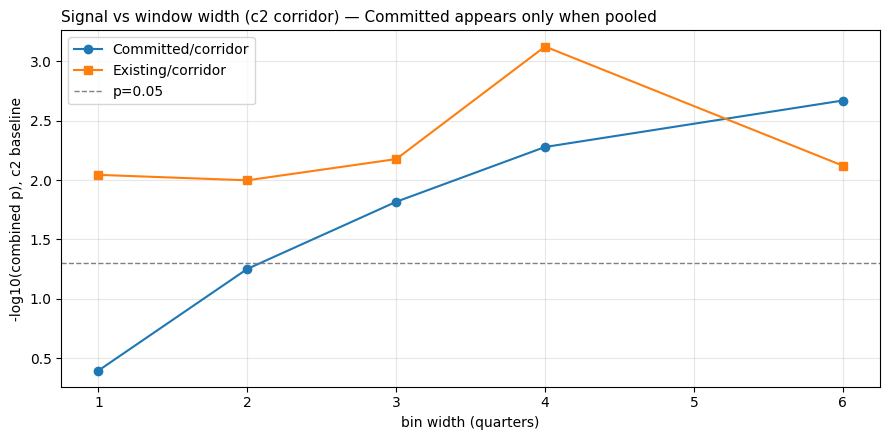

In [7]:
def cat_conc(ev,B,seed,width,minn=3):  # catchment-level, uniform 1/23 baseline
    sub=ev[ev.catchment.isin(REZ)].copy(); sub['bin']=sub.ev.map(lambda w: POS[w]//width)
    wc=sub.groupby(['bin','catchment']).size().unstack(fill_value=0).reindex(columns=REZ,fill_value=0)
    exp=np.ones(len(REZ))/len(REZ); rng=np.random.default_rng(seed); ps=[]; ns=[]
    for b,row in wc.iterrows():
        obs=row.values.astype(float); n=int(obs.sum())
        if n<minn: continue
        ns.append(n); expv=n*exp; stat=((obs-expv)**2/expv).sum(); sims=rng.multinomial(n,exp,size=B).astype(float)
        ps.append((int((((sims-expv[None,:])**2/expv[None,:]).sum(axis=1)>=stat).sum())+1)/(B+1))
    return fisher_p(ps,1/(B+1)), len(ps), int(np.median(ns)) if ns else 0
print(f"{'series':22} {'res':9} " + " ".join(f"w{w}q" for w in [1,2,3,4,6]))
for lab,ev in [('Committed',committed),('Existing(corr)',existing)]:
    line=[]
    for w in [1,2,3,4,6]: line.append(f"{cluster_conc(ev,'c2',B=20000,width=w)['combined_p']:.1e}")
    print(f"{lab:22} {'corridor':9} "+" ".join(f"{x:>7}" for x in line))
    line=[]
    for w in [1,2,3,4,6]: line.append(f"{cat_conc(ev,20000,7,w)[0]:.1e}")
    print(f"{lab:22} {'catchmnt':9} "+" ".join(f"{x:>7}" for x in line))
# plot
fig,ax=plt.subplots(figsize=(9,4.5)); ws=[1,2,3,4,6]
for lab,ev,st in [('Committed/corridor',committed,'o-'),('Existing/corridor',existing,'s-')]:
    ys=[-np.log10(cluster_conc(ev,'c2',B=20000,width=w)['combined_p']) for w in ws]; ax.plot(ws,ys,st,label=lab)
ax.axhline(-np.log10(0.05),color='grey',ls='--',lw=1,label='p=0.05')
ax.set_xlabel('bin width (quarters)'); ax.set_ylabel('-log10(combined p), c2 baseline')
ax.set_title('Signal vs window width (c2 corridor) — Committed appears only when pooled',loc='left',fontsize=11)
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

**Reading it.** Committed-corridor is null at w=1 and becomes significant only at w≥4 — a
pooled effect, not coordinated timing (and §1 shows it is unstable/artefactual). Existing-corridor
is "significant" across widths **only because these rows use the c2 baseline** — §2 shows it
dissolves under activity weighting, so these widths inherit the same baseline-sensitivity caveat.
**Catchment-level rows also use the uniform baseline and carry the same caveat** (catchment
concentration vs uniform partly reflects zone size, esp. SW-NSW). The section is methodological:
it locates *where* apparent signal lives, and confirms none of the corridor/uniform signal is
both robust and coordinated.

## §6 — Methodological finding: the c2 catchment-count baseline manufactures corridor tilts

A genuine contribution for anyone doing aggregated concentration analysis. A baseline that weights
a corridor by its **catchment count** assumes every catchment is equally likely to attract a
project. When catchment activity is **uneven within corridors**, this systematically under-expects
corridors with few high-activity catchments and over-expects corridors with many low-activity
ones — manufacturing apparent concentration that is really a baseline mismatch.

In [8]:
sh=[]
for w in post:
    a=cl_share(w,'activity')
    if a is not None: sh.append(a)
sh=np.mean(sh,axis=0)
print(f"{'corridor':22} {'catchments':>10} {'c2 share':>9} {'activity share':>15}")
for i,c in enumerate(CL):
    print(f"  {c:22} {NCAT[c]:>8} {C2[i]:>9.3f} {sh[i]:>15.3f}")
print("\nWorked example (corrected-Existing aggregate, c2 -> activity-weighted ratio):")
print("  Eastern SA   1.65x -> 0.99x   (c2 under-expects it: 2 catchments, 0.143 share, 0.235 of activity)")
print("  Southern QLD 0.44x -> 1.17x   (c2 over-expects it: 5 low-activity catchments, 0.357 share, 0.136 of activity)")

corridor               catchments  c2 share  activity share
  Central-Northern NSW          3     0.214           0.291
  Southern QLD                  5     0.357           0.136
  Western Victoria              2     0.143           0.184
  Northern Victoria             2     0.143           0.155
  Eastern SA                    2     0.143           0.235

Worked example (corrected-Existing aggregate, c2 -> activity-weighted ratio):
  Eastern SA   1.65x -> 0.99x   (c2 under-expects it: 2 catchments, 0.143 share, 0.235 of activity)
  Southern QLD 0.44x -> 1.17x   (c2 over-expects it: 5 low-activity catchments, 0.357 share, 0.136 of activity)


**Takeaway.** Eastern SA (2 catchments, high activity) and Southern QLD (5 catchments, low
activity) are the clearest cases: under c2 they look strongly over/under-represented; under an
activity-weighted baseline both revert to ≈1×. **Any corridor/zone-aggregated concentration claim
should use an activity-weighted (or hosting-capacity) baseline, not catchment count.** This is the
methodological yield of the notebook even though the substantive corridor results are null.

## §7 — Integrated picture with notebook 07

- **Announcement stage (nb07):** real, at the **catchment** level — Proposed/Anticipated
  first-entries concentrate cross-catchmently within quarters (p ≈ 3.7e-18), survives permutation.
  (nb07's cluster-level tests use an exposure/activity baseline, so they are **not** exposed to the
  §6 c2 catchment-count bias.)
- **Committed stage (nb08 §1):** the announcement-stage concentration **does not carry through to
  committed capital at the corridor level** — quarterly null, pooled signal unstable/artefactual.
- **Energisation (nb08 §3):** robust concentration survives **only at SW-NSW, a single catchment**,
  with an ambiguous (possibly construction-wave) mechanism.
- **No corridor-level result is robust** at any lifecycle status.

**Structural finding: the corridor — the SLD-topology grouping — is not the unit at which this
phenomenon operates.** Where concentration is real it is at the **catchment** scale (nb07
announcements; SW-NSW energisation). Aggregating to transmission corridors does not strengthen it
and, with a catchment-count baseline, manufactures spurious tilts. If there is a herding
mechanism, it acts on individual REZ catchments, not on the multi-catchment corridors defined from
network topology.

## §8 — Caveats and honest scope

1. **This is a predominantly null result.** The notebook set out to test status-stratified
   *corridor* herding and found: Committed-corridor null; Existing-corridor null/c2-artefact;
   Withdrawn untestable. The single positive — SW-NSW energisation — is **one catchment**, not a
   corridor, with an **ambiguous mechanism** (energisation timing ≠ decision herding). The corridor
   framing is **not supported**.
2. **c2 baseline bias (§6).** The equal-per-catchment baseline manufactures corridor tilts under
   uneven within-corridor activity; the activity-weighted baseline is the honest one. Catchment-
   level and multi-timescale rows that use the uniform/c2 baseline inherit this caveat.
3. **Small cells / bootstrap.** Expected per-cell counts are small; all tests are multinomial-/
   binomial-bootstrap calibrated (asymptotic chi-square would be anti-conservative). Bootstrap
   floor 1/(B+1).
4. **Cross-resolution non-independence.** Catchment/corridor are re-cuts of the same events;
   significance across them is not independent confirmation.
5. **Leak-corrected Existing** excludes projects first listed already-operational (no observed
   Committed phase); it captures genuine within-window energisations but its early windows include
   maturation of the pre-2020 committed pipeline.
6. **Withdrawn is the most interesting, least testable series.** 21 events over 2020–2025 cannot
   support a concentration test; resolves only with more years of panel data.
7. **Establishes pattern, not mechanism, and not causation.** Even the SW-NSW result is
   concentration *consistent-with* herding; the causal herding→constraint question is the separate
   Test 5. A hosting-capacity baseline (to test *excess* concentration) remains future work.

**Bottom line.** A clean, well-verified null is the result. The one robust positive (SW-NSW
energisation, single catchment) is reported as such, and the corridor-level herding hypothesis is
not supported.